# Import libraries

In [48]:
import pandas as pd 
import numpy as np 
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.cluster import KMeans

import umap.umap_ as umap

# Looking for a numer of clusters

In [2]:
out_path = r"../data/df_with_fulltext_embedding.csv"

In [3]:
df = pd.read_csv(out_path)

In [4]:
df

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,...,tag_4,tag_5,tag_6,tag_7,tag_8,body_length,answer_length,tags_combined,ticket_text,embedding
0,wesentlicher sicherheitsvorfall,sehr geehrtes support-team n nich möchte einen...,vielen dank für die meldung des kritischen sic...,Incident,Technical Support,high,de,51,security,outage,...,data breach,NaN,NaN,NaN,NaN,741,634,security outage disruption data breach,wesentlicher sicherheitsvorfall sehr geehrtes ...,[-1.41057558e-02 -2.59171501e-02 -9.80596058e-...
1,account disruption,dear customer support team n ni am writing to ...,thank you for reaching out name we are aware o...,Incident,Technical Support,high,en,51,account,disruption,...,it,tech support,NaN,NaN,NaN,534,488,account disruption outage it tech support,account disruption dear customer support team ...,[ 8.52196664e-03 3.94238830e-02 9.63402633e-...
2,query about smart home system integration feat...,dear customer support team n ni hope this mess...,thank you for your inquiry our products suppor...,Request,Returns and Exchanges,medium,en,51,product,feature,...,NaN,NaN,NaN,NaN,NaN,526,494,product feature tech support,query about smart home system integration feat...,[-4.67852466e-02 -3.89463105e-03 6.24952912e-...
3,inquiry regarding invoice details,dear customer support team n ni hope this mess...,we appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51,billing,payment,...,documentation,feedback,NaN,NaN,NaN,593,532,billing payment account documentation feedback,inquiry regarding invoice details dear custome...,[-0.11088825 0.03278524 0.04811986 -0.029883...
4,question about marketing agency software compa...,dear support team n ni hope this message reach...,thank you for your inquiry our product support...,Problem,Sales and Pre-Sales,medium,en,51,product,feature,...,tech support,NaN,NaN,NaN,NaN,667,268,product feature feedback tech support,question about marketing agency software compa...,[-1.65767912e-02 3.69704212e-03 2.65973117e-...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28582,performance problem with data analytics tool,the data analytics tool experiences sluggish p...,we are addressing the performance issue with t...,Incident,Technical Support,high,en,400,performance,it,...,NaN,NaN,NaN,NaN,NaN,74,266,performance it tech support,performance problem with data analytics tool t...,[-0.0470882 0.08013243 -0.07766346 -0.006056...
28583,datensperrung in der kundschaftsbetreuung,es gab einen datensperrungsunfall bei dem unge...,ich kann ihnen bei dem datensperrungsunfall he...,Incident,Product Support,high,de,400,security,it,...,bug,NaN,NaN,NaN,NaN,406,397,security it tech support bug,datensperrung in der kundschaftsbetreuung es g...,[ 2.64201593e-03 6.19929247e-02 -1.18690850e-...
28584,problem mit der videokonferenz-software heute,wichtigere sitzungen wurden unterbrochen durch...,sehr geehrte r name leider wurde das problem m...,Incident,Human Resources,low,de,400,bug,performance,...,it,tech support,NaN,NaN,NaN,235,579,bug performance network it tech support,problem mit der videokonferenz-software heute ...,[ 9.49101523e-04 3.63543862e-03 -3.31395604e-...
28585,update request for saas platform integration f...,requesting an update on the integration featur...,received your request for updates on the integ...,Change,IT Support,high,en,400,feature,it,...,NaN,NaN,NaN,NaN,NaN,281,264,feature it tech support,update request for saas platform integration f...,[-3.65574285e-02 2.11781152e-02 6.48051966e-...


In [5]:
def fix_emb_spaces(x):
    if isinstance(x, str):
        x = x.replace('\n', ' ').strip()      # убрать переносы строк
        x = x.strip('[]')                     # убрать []
        x = x.split()                         # разбить по пробелам
        return np.array([float(n) for n in x], dtype=np.float32)
    return np.array(x, dtype=np.float32)

df['embedding'] = df['embedding'].apply(fix_emb_spaces)
X = np.vstack(df['embedding'].values)


In [10]:
# Преобразуем embeddings в numpy матрицу if нужно
X = np.vstack(df['embedding'].values)

k_values = list(range(4, 14))

inertias = []
sil_scores = []
ch_scores = []

for k in k_values:
    print(f"Training KMeans for k={k}...")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(X)
    
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X, labels))
    ch_scores.append(calinski_harabasz_score(X, labels))

print("Done!")


Training KMeans for k=4...
Training KMeans for k=5...
Training KMeans for k=6...
Training KMeans for k=7...
Training KMeans for k=8...
Training KMeans for k=9...
Training KMeans for k=10...
Training KMeans for k=11...
Training KMeans for k=12...
Training KMeans for k=13...
Done!


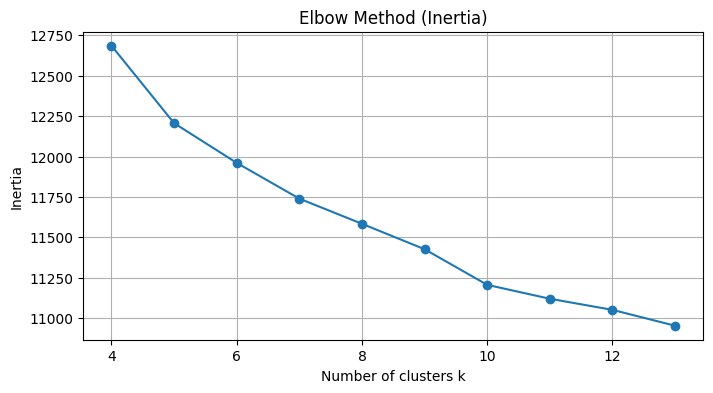

In [11]:
plt.figure(figsize=(8,4))
plt.plot(k_values, inertias, marker='o')
plt.title("Elbow Method (Inertia)")
plt.xlabel("Number of clusters k")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

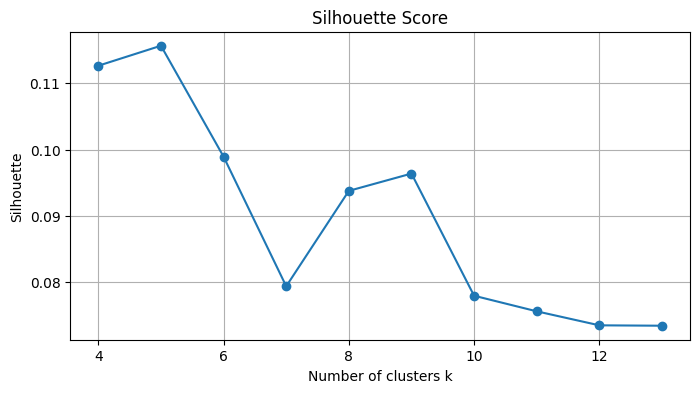

In [12]:
plt.figure(figsize=(8,4))
plt.plot(k_values, sil_scores, marker='o')
plt.title("Silhouette Score")
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette")
plt.grid(True)
plt.show()


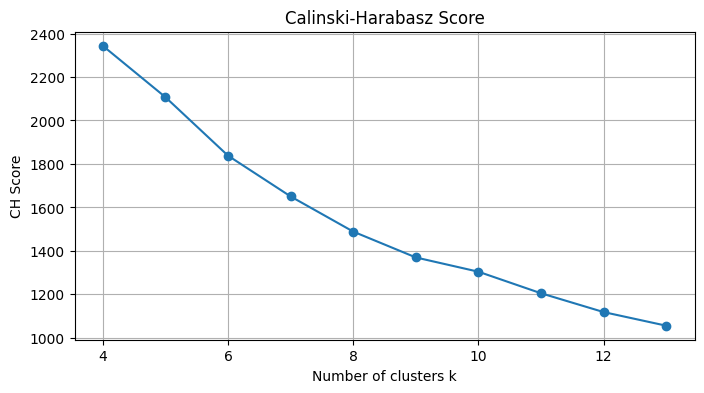

In [13]:
plt.figure(figsize=(8,4))
plt.plot(k_values, ch_scores, marker='o')
plt.title("Calinski-Harabasz Score")
plt.xlabel("Number of clusters k")
plt.ylabel("CH Score")
plt.grid(True)
plt.show()

# Clusterring

In [14]:
n_clusters = 9

In [15]:
X = np.vstack(df['embedding'].values)

kmeans = KMeans(n_clusters=n_clusters, random_state=42)
df['cluster'] = kmeans.fit_predict(X)

In [17]:
display(df[['ticket_text', 'cluster']].head(10))

,ticket_text,cluster
0,wesentlicher sicherheitsvorfall sehr geehrtes ...,3
1,account disruption dear customer support team ...,7
2,query about smart home system integration feat...,5
3,inquiry regarding invoice details dear custome...,7
4,question about marketing agency software compa...,5
5,feature query dear customer support n ni hope ...,5
6,system interruptions dear customer support tea...,4
7,connectivity problems with printer on macbook ...,8
8,anfrage nach detaillierten angaben zur systema...,5
9,anfrage zur klärung der auswirkungen eines ser...,4


In [ ]:
out_path = r"../data/df_with_fulltext_embedding_and_clusters.csv"
df.to_csv(out_path, index=False)
print("Saved to", out_path)

Saved to C:\Workspace\Python Playground\df_with_embedding_and_clusters.csv


## Name of clusters

In [ ]:
df.groupby('cluster')['ticket_text'].apply(lambda x: x.sample(10))

cluster       
0        24383             bug performance hardware it tech support
         8992     bug performance outage disruption recovery sof...
         12855             bug performance it tech support feedback
         5479     bug performance disruption recovery software s...
         4280              bug performance outage technical support
                                        ...                        
8        5321     network disruption hardware firmware connectivity
         19163                      bug performance it tech support
         1187     security data storage access issue permission ...
         21806        bug performance it tech support documentation
         11597                      bug performance it tech support
Name: tags_combined, Length: 90, dtype: object

In [19]:
def top_words(tags, n=15):
    words = []
    for t in tags:
        t = re.sub(r"[^a-zA-Z ]", " ", t.lower())
        words.extend(t.split())
    return Counter(words).most_common(n)


In [ ]:
cluster_groups = (
    df.groupby("cluster")['ticket_text']
    .apply(list)
    .sort_index()
)

In [21]:
cluster_groups

cluster
0    [alert disruption performance software tech su...
1    [marketing feedback sales lead, marketing feed...
2    [organization feedback support documentation, ...
3    [security outage disruption data breach, secur...
4    [outage disruption performance it tech support...
5    [product feature tech support, product feature...
6    [feature account marketing performance automat...
7    [account disruption outage it tech support, bi...
8    [network hardware performance bug compatibilit...
Name: tags_combined, dtype: object

In [22]:
for cid, tags in cluster_groups.items():
    print("="*80)
    print(f"CLUSTER {cid}")
    print("Tags count:", len(tags))
    print("Top words:", top_words(tags, n=10))
    print("Example tags:", tags[:12])
    print()


CLUSTER 0
Tags count: 3203
Top words: [('performance', 3016), ('support', 2330), ('tech', 2190), ('bug', 2179), ('it', 2126), ('disruption', 855), ('outage', 627), ('software', 477), ('documentation', 472), ('recovery', 466)]
Example tags: ['alert disruption performance software tech support', 'maintenance outage disruption it tech support', 'bug performance disruption tech support', 'outage disruption network performance server data pipeline real time analytics it', 'hardware software outage disruption performance it', 'bug outage disruption performance tech support', 'bug outage disruption performance', 'performance outage disruption it tech support', 'disruption outage performance support', 'bug performance feature documentation it tech support', 'performance bug feature analytics', 'outage disruption performance analytics it tech support']

CLUSTER 1
Tags count: 2515
Top words: [('feedback', 2087), ('sales', 1470), ('feature', 1101), ('support', 1004), ('tech', 874), ('it', 860), (

# Mapping

In [23]:
cluster_mapping = {
    0: "Critical Outages & Performance Disruptions",
    1: "Sales, Product Feedback & Marketing Insights",
    2: "Mixed Feedback: Performance, Marketing & IT Support",
    3: "Security, Compliance & Data Protection",
    4: "IT Outages, Network Failures & System Recovery",
    5: "Product Features, Documentation & Technical Support",
    6: "Feature Requests, Product Improvements & Feedback",
    7: "Billing, Payments, Refunds & Account Issues",
    8: "Network Connectivity, Hardware Issues & Tech Support",
}

In [24]:
df['cluster_name'] = df['cluster'].map(cluster_mapping)

In [ ]:
out_path = r"../data/df_with_fulltext_cluster_name.csv"
df.to_csv(out_path, index=False)
print("Saved to", out_path)

Saved to C:\Workspace\Python Playground\df_with_cluster_name.csv


# Visualization 

In [ ]:


plt.style.use("seaborn-v0_8-whitegrid")


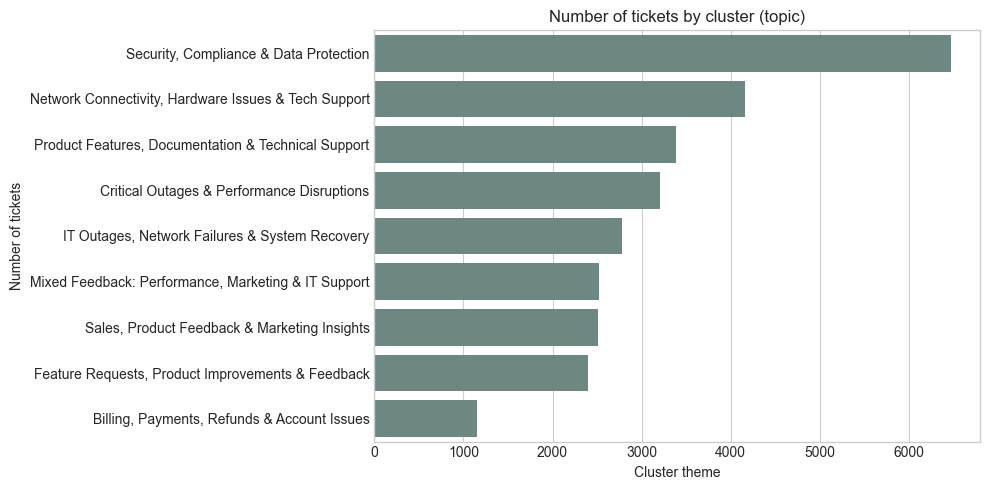

In [40]:
plt.figure(figsize=(10, 5))
sns.countplot( y=df["cluster_name"], order=df["cluster_name"].value_counts().index, color='#698c85')
plt.title("Number of tickets by cluster (topic)")
plt.xlabel("Cluster theme")
plt.ylabel("Number of tickets")
plt.tight_layout()
plt.show()



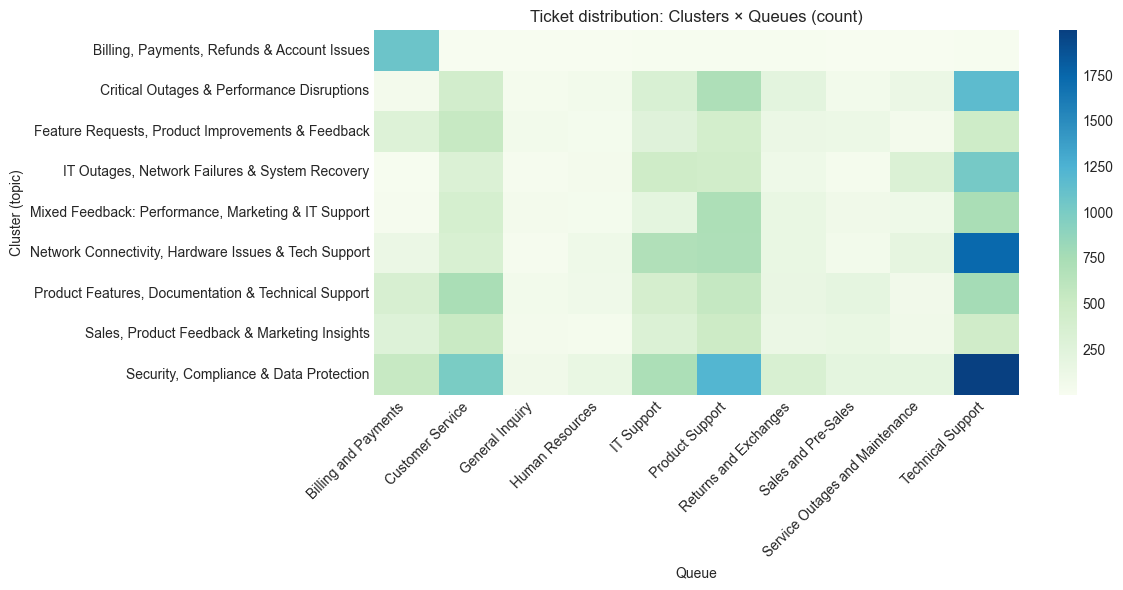

In [41]:
ct_cluster_queue = pd.crosstab(df['cluster_name'], df['queue'])

plt.figure(figsize=(12, 6))
sns.heatmap(ct_cluster_queue, annot=False, cmap="GnBu")
plt.title("Ticket distribution: Clusters × Queues (count)")
plt.xlabel("Queue")
plt.ylabel("Cluster (topic)")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


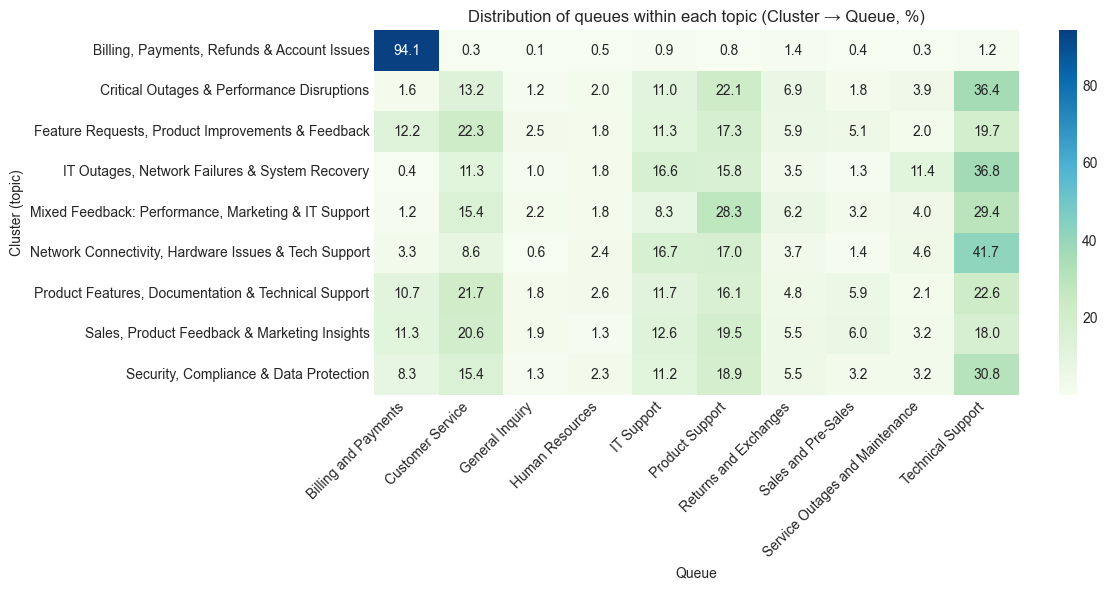

In [42]:
ct_row = pd.crosstab(df['cluster_name'], df['queue'], normalize='index') * 100

plt.figure(figsize=(12, 6))
sns.heatmap(ct_row, annot=True, fmt=".1f", cmap="GnBu")
plt.title("Distribution of queues within each topic (Cluster → Queue, %)")
plt.xlabel("Queue")
plt.ylabel("Cluster (topic)")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


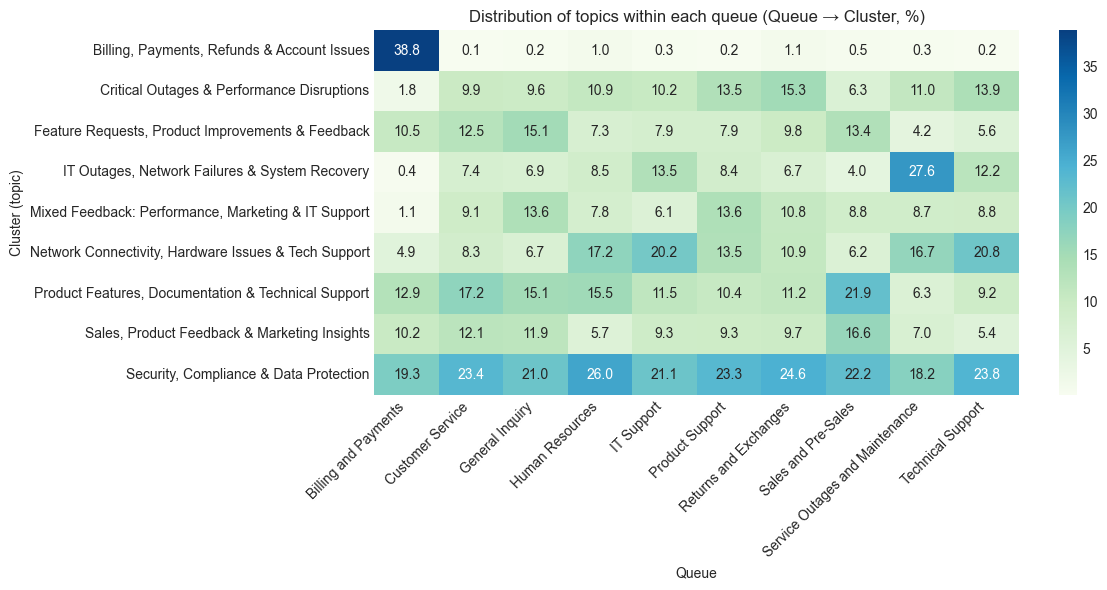

In [43]:
ct_col = pd.crosstab(df['cluster_name'], df['queue'], normalize='columns') * 100

plt.figure(figsize=(12, 6))
sns.heatmap(ct_col, annot=True, fmt=".1f", cmap="GnBu")
plt.title("Distribution of topics within each queue (Queue → Cluster, %)")
plt.xlabel("Queue")
plt.ylabel("Cluster (topic)")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


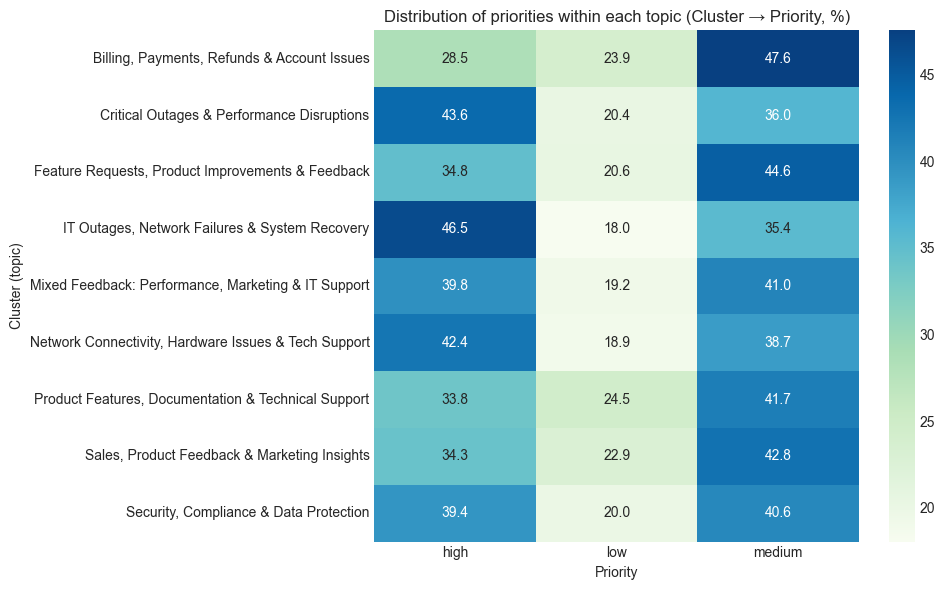

In [45]:
ct_cl_prio = pd.crosstab(df['cluster_name'], df['priority'], normalize='index') * 100

plt.figure(figsize=(10, 6))
sns.heatmap(ct_cl_prio, annot=True, fmt=".1f", cmap="GnBu")
plt.title("Distribution of priorities within each topic (Cluster → Priority, %)")
plt.xlabel("Priority")
plt.ylabel("Cluster (topic)")
plt.tight_layout()
plt.show()


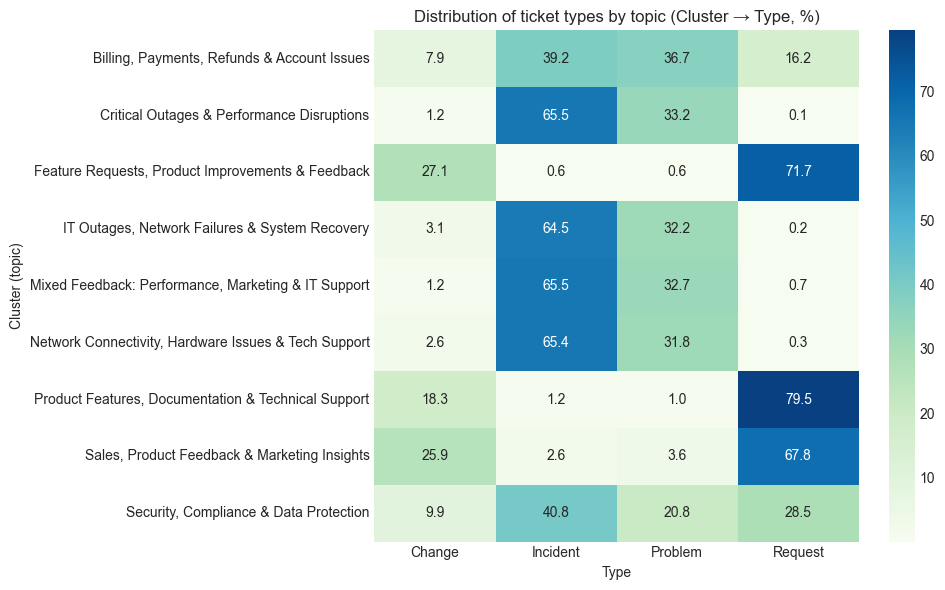

In [47]:
ct_cl_type = pd.crosstab(df['cluster_name'], df['type'], normalize='index') * 100

plt.figure(figsize=(10, 6))
sns.heatmap(ct_cl_type, annot=True, fmt=".1f", cmap="GnBu")
plt.title("Distribution of ticket types by topic (Cluster → Type, %)")
plt.xlabel("Type")
plt.ylabel("Cluster (topic)")
plt.tight_layout()
plt.show()


# UMAP

In [49]:
def fix_emb_spaces(x):
    if isinstance(x, str):
        x = x.replace('\n', ' ').strip()
        x = x.strip('[]')
        x = x.split()
        return np.array([float(n) for n in x], dtype=np.float32)
    return np.array(x, dtype=np.float32)


In [50]:

X = np.vstack(df['embedding'].apply(fix_emb_spaces).values)

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric='cosine',
    random_state=42
)
X_umap = reducer.fit_transform(X)


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [51]:

df['umap_x'] = X_umap[:, 0]
df['umap_y'] = X_umap[:, 1]


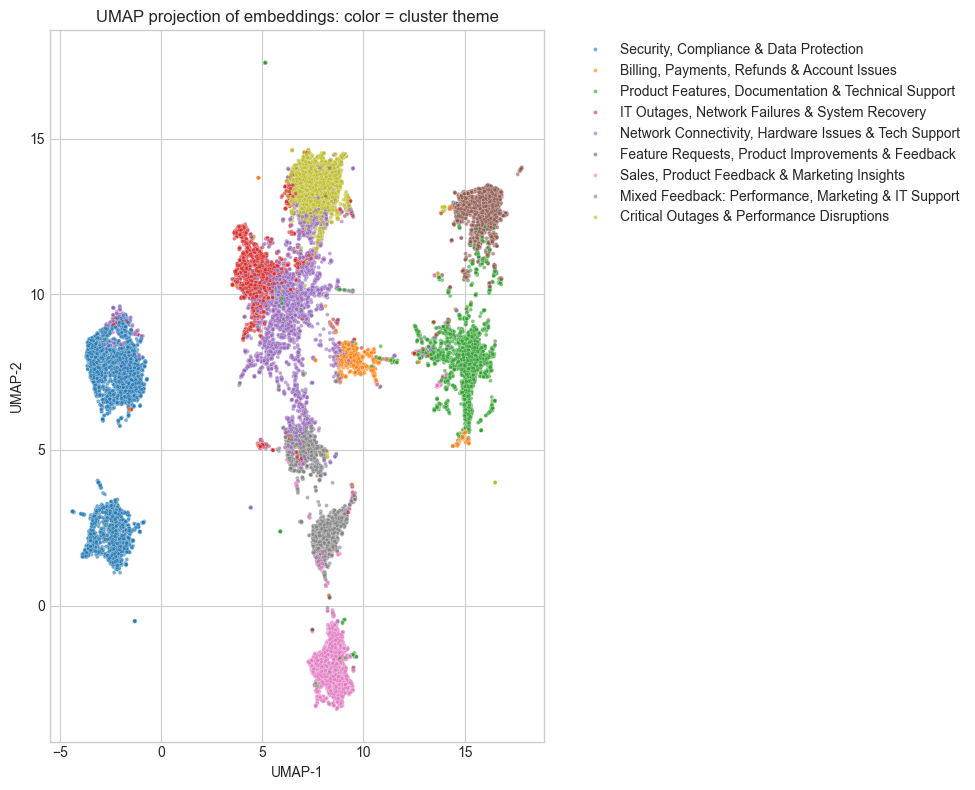

In [52]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df,
    x='umap_x',
    y='umap_y',
    hue='cluster_name',
    s=8,
    alpha=0.6,
    legend='full'
)
plt.title("UMAP projection of embeddings: color = cluster theme")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


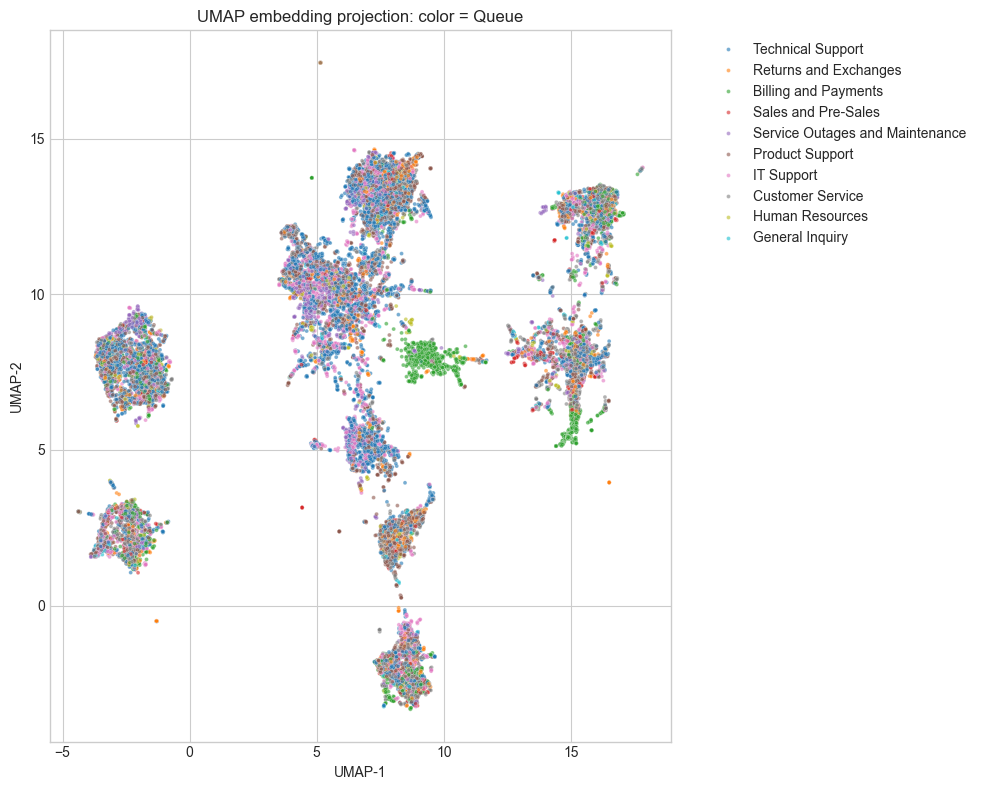

In [53]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df,
    x='umap_x',
    y='umap_y',
    hue='queue',
    s=8,
    alpha=0.6,
    legend='full'
)
plt.title("UMAP embedding projection: color = Queue")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
